In [1]:
from gettext import translation

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from fontTools.diff import color

customers = pd.read_csv('../data/olist_customers_dataset.csv')
geolocation = pd.read_csv('../data/olist_geolocation_dataset.csv')
order_items = pd.read_csv('../data/olist_order_items_dataset.csv')
order_payments = pd.read_csv('../data/olist_order_payments_dataset.csv')
order_reviews = pd.read_csv('../data/olist_order_reviews_dataset.csv')
order=pd.read_csv('../data/olist_orders_dataset.csv')
products = pd.read_csv('../data/olist_products_dataset.csv')
sellers = pd.read_csv('../data/olist_sellers_dataset.csv')
categories = pd.read_csv('../data/product_category_name_translation.csv')

Data Understanding

In [2]:
customers.info()
customers


<class 'pandas.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 5 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   customer_id               99441 non-null  str  
 1   customer_unique_id        99441 non-null  str  
 2   customer_zip_code_prefix  99441 non-null  int64
 3   customer_city             99441 non-null  str  
 4   customer_state            99441 non-null  str  
dtypes: int64(1), str(4)
memory usage: 11.0 MB


,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP
...,...,...,...,...,...
99436,17ddf5dd5d51696bb3d7c6291687be6f,1a29b476fee25c95fbafc67c5ac95cf8,3937,sao paulo,SP
99437,e7b71a9017aa05c9a7fd292d714858e8,d52a67c98be1cf6a5c84435bd38d095d,6764,taboao da serra,SP
99438,5e28dfe12db7fb50a4b2f691faecea5e,e9f50caf99f032f0bf3c55141f019d99,60115,fortaleza,CE
99439,56b18e2166679b8a959d72dd06da27f9,73c2643a0a458b49f58cea58833b192e,92120,canoas,RS


In [3]:
rows,column=customers.shape
print("rows:",rows)
print("column:",column)

rows: 99441
column: 5


In [4]:
#customers.columns
customers.columns.tolist()

['customer_id',
 'customer_unique_id',
 'customer_zip_code_prefix',
 'customer_city',
 'customer_state']

In [5]:
#customers.duplicated().sum()
customers[customers.duplicated(keep=False)]

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state


In [6]:
customers["customer_state"].unique()

<ArrowStringArray>
['SP', 'SC', 'MG', 'PR', 'RJ', 'RS', 'PA', 'GO', 'ES', 'BA', 'MA', 'MS', 'CE',
 'DF', 'RN', 'PE', 'MT', 'AM', 'AP', 'AL', 'RO', 'PB', 'TO', 'PI', 'AC', 'SE',
 'RR']
Length: 27, dtype: str

In [7]:
customers.isnull().sum()

customer_id                 0
customer_unique_id          0
customer_zip_code_prefix    0
customer_city               0
customer_state              0
dtype: int64

In [8]:
#order.shape
rows,column=order.shape
print("rows:",rows)
print("column:",column)

rows: 99441
column: 8


In [9]:
#order.columns
order.columns.tolist()

['order_id',
 'customer_id',
 'order_status',
 'order_purchase_timestamp',
 'order_approved_at',
 'order_delivered_carrier_date',
 'order_delivered_customer_date',
 'order_estimated_delivery_date']

In [10]:
order.dtypes

order_id                         str
customer_id                      str
order_status                     str
order_purchase_timestamp         str
order_approved_at                str
order_delivered_carrier_date     str
order_delivered_customer_date    str
order_estimated_delivery_date    str
dtype: object

In [11]:
#order.nunique
order["order_status"].unique()

<ArrowStringArray>
[  'delivered',    'invoiced',     'shipped',  'processing', 'unavailable',
    'canceled',     'created',    'approved']
Length: 8, dtype: str

In [12]:
order.isnull().sum()

order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
dtype: int64

In [13]:
order.duplicated().sum()

np.int64(0)

In [14]:
rows,columns =geolocation.shape
print("rows:",rows)
print("column:",column)

rows: 1000163
column: 8


In [15]:
geolocation.columns.tolist()

['geolocation_zip_code_prefix',
 'geolocation_lat',
 'geolocation_lng',
 'geolocation_city',
 'geolocation_state']

In [16]:
#geolocation.info
geolocation.dtypes

geolocation_zip_code_prefix      int64
geolocation_lat                float64
geolocation_lng                float64
geolocation_city                   str
geolocation_state                  str
dtype: object

In [17]:
geolocation.isnull().sum()

geolocation_zip_code_prefix    0
geolocation_lat                0
geolocation_lng                0
geolocation_city               0
geolocation_state              0
dtype: int64

In [18]:
geolocation.duplicated().sum()

np.int64(261831)

In [19]:
order_items.isnull().sum()

order_id               0
order_item_id          0
product_id             0
seller_id              0
shipping_limit_date    0
price                  0
freight_value          0
dtype: int64

In [20]:
order_items.duplicated().sum()

np.int64(0)

In [21]:
order_items["order_item_id"].isnull().sum()

np.int64(0)

In [22]:
order_items.columns.tolist()

['order_id',
 'order_item_id',
 'product_id',
 'seller_id',
 'shipping_limit_date',
 'price',
 'freight_value']

In [23]:
rows,columns =order_items.shape
print("rows:",rows)
print("column:",column)

rows: 112650
column: 8


In [24]:
#order_payments.isnull().sum()
#order_items.columns.tolist()
#order_payments.dtypes
#order_items.duplicated().sum()

#rows,columns=order_payments.shape
#print("rows:",rows)
#print("columns:",columns)

order_payments["payment_value"].unique()

array([ 99.33,  24.39,  65.71, ..., 205.71, 100.55, 363.31],
      shape=(29077,))

In [25]:
#order_reviews.isnull().sum()
#order_reviews.columns.tolist()
#order_reviews.dtypes
#order_reviews.duplicated().sum()

#rows,columns=order_reviews.shape
#print("rows:",rows)
#print("columns:",columns)


#order_reviews.nunique()

order_reviews["review_score"].unique()

array([4, 5, 1, 3, 2])

In [26]:
#products.isnull().sum()
#products.columns.tolist()
#products.dtypes
#products.duplicated().sum()

#rows,columns=products.shape
#print("rows:",rows)
#print("columns:",columns)


#products.nunique()

products["product_category_name"].unique()

<ArrowStringArray>
[                                    'perfumaria',
                                          'artes',
                                  'esporte_lazer',
                                          'bebes',
                          'utilidades_domesticas',
                          'instrumentos_musicais',
                                     'cool_stuff',
                               'moveis_decoracao',
                               'eletrodomesticos',
                                     'brinquedos',
                                'cama_mesa_banho',
               'construcao_ferramentas_seguranca',
                         'informatica_acessorios',
                                   'beleza_saude',
                               'malas_acessorios',
                             'ferramentas_jardim',
                              'moveis_escritorio',
                                     'automotivo',
                                    'eletronicos',
            

In [27]:
sellers.isnull().sum()

seller_id                 0
seller_zip_code_prefix    0
seller_city               0
seller_state              0
dtype: int64

In [28]:
categories.isnull().sum()


product_category_name            0
product_category_name_english    0
dtype: int64

Data Cleaning

In [29]:
order.columns.tolist()

['order_id',
 'customer_id',
 'order_status',
 'order_purchase_timestamp',
 'order_approved_at',
 'order_delivered_carrier_date',
 'order_delivered_customer_date',
 'order_estimated_delivery_date']

In [30]:
order.columns = order.columns.str.strip()

In [31]:
order['order_delivered_carrier_date'] =pd.to_datetime(order['order_delivered_carrier_date'])
order['order_delivered_carrier_date']

0       2017-10-04 19:55:00
1       2018-07-26 14:31:00
2       2018-08-08 13:50:00
3       2017-11-22 13:39:59
4       2018-02-14 19:46:34
                ...        
99436   2017-03-10 11:18:03
99437   2018-02-07 23:22:42
99438   2017-08-28 20:52:26
99439   2018-01-12 15:35:03
99440   2018-03-09 22:11:59
Name: order_delivered_carrier_date, Length: 99441, dtype: datetime64[us]

In [32]:
before= len(order)

In [33]:
date_cols=[
    'order_purchase_timestamp',
    'order_approved_at',
    'order_delivered_carrier_date',
    'order_delivered_customer_date',
    'order_estimated_delivery_date'
]
for col in date_cols:
    order[col] = pd.to_datetime(order[col])


In [34]:
order[date_cols].dtypes

order_purchase_timestamp         datetime64[us]
order_approved_at                datetime64[us]
order_delivered_carrier_date     datetime64[us]
order_delivered_customer_date    datetime64[us]
order_estimated_delivery_date    datetime64[us]
dtype: object

In [35]:
order.isnull().mean()*100

order_id                         0.000000
customer_id                      0.000000
order_status                     0.000000
order_purchase_timestamp         0.000000
order_approved_at                0.160899
order_delivered_carrier_date     1.793023
order_delivered_customer_date    2.981668
order_estimated_delivery_date    0.000000
dtype: float64

In [36]:
after=len(order)
print('before:',before)
print('after:',after)
print('removed rows:',after-before)

before: 99441
after: 99441
removed rows: 0


In [37]:
order.duplicated().sum()

np.int64(0)

In [38]:
categories['product_category_name_english'].unique()


<ArrowStringArray>
[                          'health_beauty',
                   'computers_accessories',
                                    'auto',
                          'bed_bath_table',
                         'furniture_decor',
                          'sports_leisure',
                               'perfumery',
                              'housewares',
                               'telephony',
                           'watches_gifts',
                              'food_drink',
                                    'baby',
                              'stationery',
                  'tablets_printing_image',
                                    'toys',
                         'fixed_telephony',
                            'garden_tools',
                'fashion_bags_accessories',
                        'small_appliances',
                          'consoles_games',
                                   'audio',
                           'fashion_shoes',
             

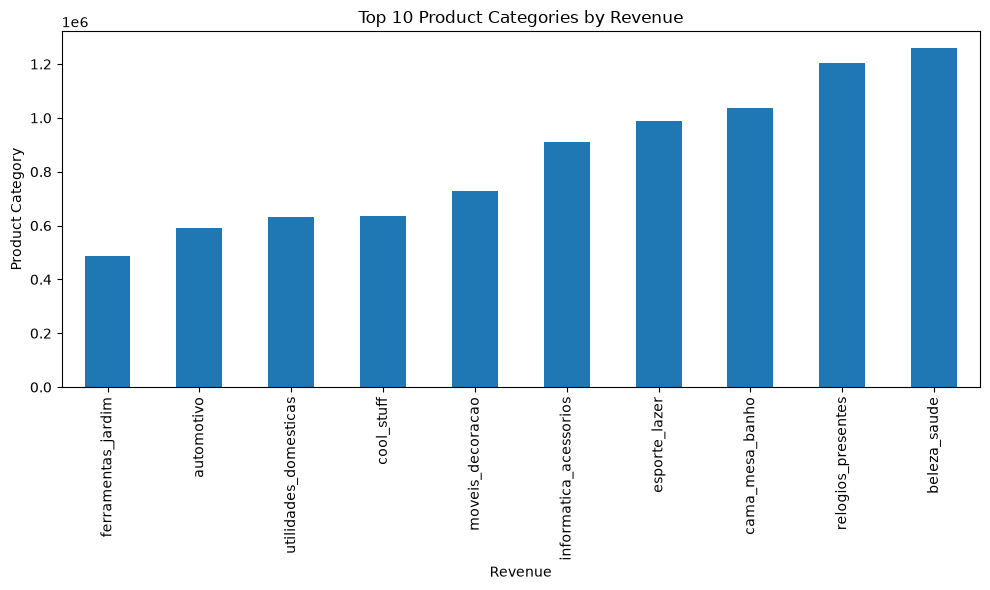

In [119]:
# 1. Merge order_items with products
product_sales = pd.merge(
    order_items,
    products,
    on="product_id",
    how="left"
)

# 2. Calculate revenue by product category
top_products = (
    product_sales
    .groupby("product_category_name")["price"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

# 3. Plot Top 10 Product Categories
plt.figure(figsize=(10, 6))

top_products.sort_values().plot(kind="bar")

plt.title("Top 10 Product Categories by Revenue")
plt.xlabel("Revenue")
plt.ylabel("Product Category")

plt.tight_layout()

plt.savefig("../dashboard/assets/Top 10 Product Categories by Revenue.png")
plt.show()

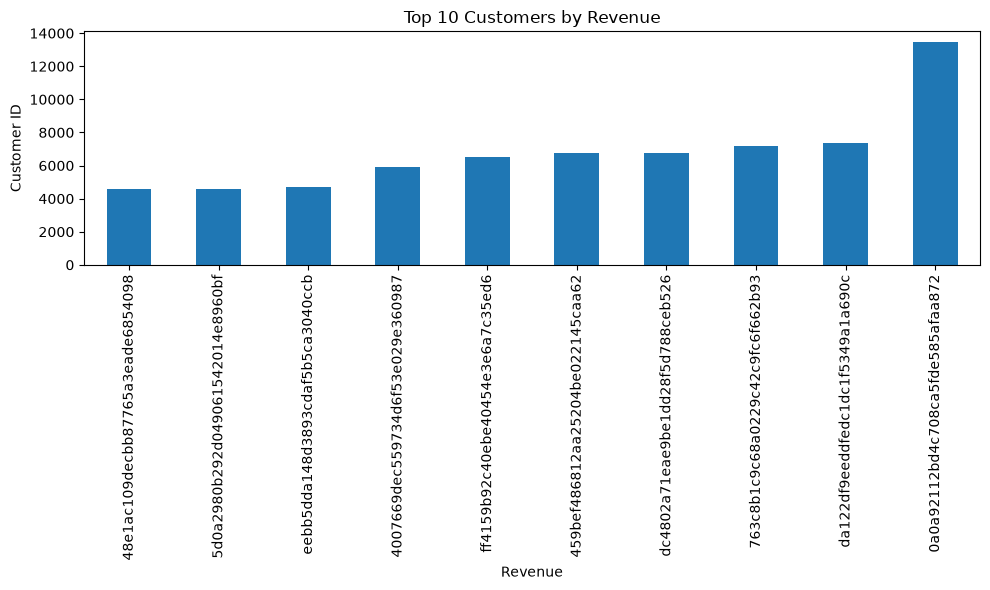

In [118]:

# Merge order_items with orders
customer_sales = pd.merge(
    order_items,
    order[["order_id", "customer_id"]],
    on="order_id",
    how="left"
)

# Merge with customers
customer_sales = pd.merge(
    customer_sales,
    customers[["customer_id", "customer_unique_id"]],
    on="customer_id",
    how="left"
)

# Top 10 customers by revenue
top_customers = (
    customer_sales
    .groupby("customer_unique_id")["price"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

# Plot
plt.figure(figsize=(10, 6))

top_customers.sort_values().plot(kind="bar")

plt.title("Top 10 Customers by Revenue")
plt.xlabel("Revenue")
plt.ylabel("Customer ID")

plt.tight_layout()

plt.savefig('../dashboard/assets/Top 10 Customers by Revenue.png')
plt.show()

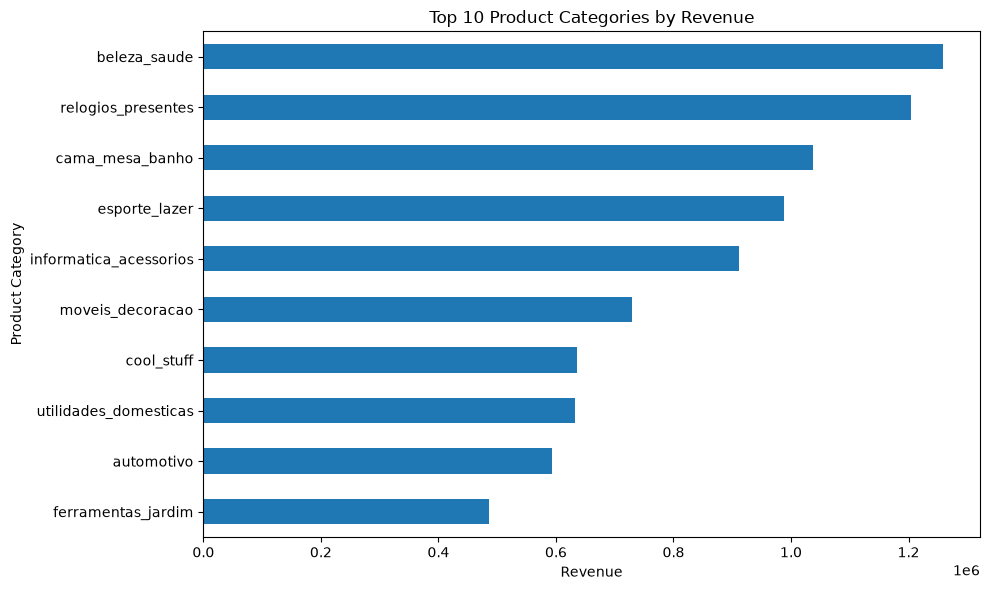

In [117]:
# Merge order_items with products
product_sales = pd.merge(
    order_items,
    products[["product_id", "product_category_name"]],
    on="product_id",
    how="left"
)

# Calculate revenue
category_revenue = (
    product_sales
    .groupby("product_category_name")["price"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

# Plot
plt.figure(figsize=(10, 6))

category_revenue.sort_values().plot(kind="barh")

plt.title("Top 10 Product Categories by Revenue")
plt.xlabel("Revenue")
plt.ylabel("Product Category")

plt.tight_layout()

plt.savefig('../dashboard/assets/Top 10 Product Categories by Revenue.png')
plt.show()

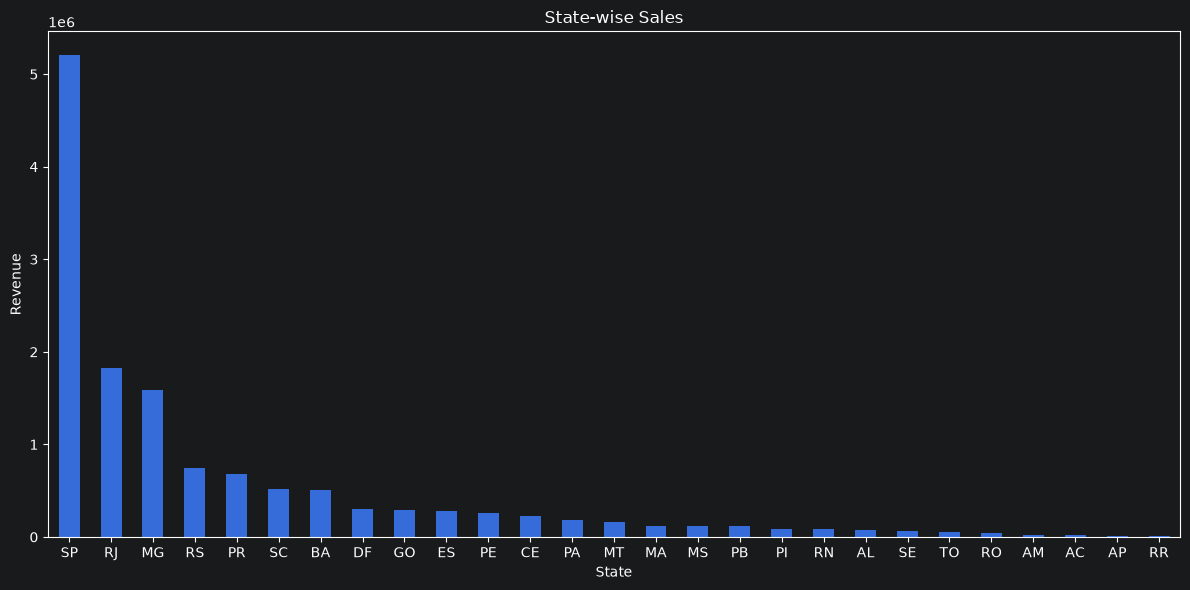

In [123]:

# Merge order_items with orders
state_sales = pd.merge(
    order_items,
    order[["order_id", "customer_id"]],
    on="order_id",
    how="left"
)

# Merge with customers
state_sales = pd.merge(
    state_sales,
    customers[["customer_id", "customer_state"]],
    on="customer_id",
    how="left"
)

# Calculate state-wise revenue
state_revenue = (
    state_sales
    .groupby("customer_state")["price"]
    .sum()
    .sort_values(ascending=False)
)

# Plot
plt.figure(figsize=(12, 6))

state_revenue.plot(kind="bar")

plt.title("State-wise Sales")
plt.xlabel("State")
plt.ylabel("Revenue")

plt.xticks(rotation=0)

plt.tight_layout()
plt.savefig('../dashboard/assets/State-wise Sales.png')
plt.show()

In [39]:
order['order_id'].nunique()
#total_orders=order['order_id'].nunique()
#print(total_orders)

99441

In [40]:
order_payments.columns.tolist()


['order_id',
 'payment_sequential',
 'payment_type',
 'payment_installments',
 'payment_value']

In [41]:
order.columns.tolist()

['order_id',
 'customer_id',
 'order_status',
 'order_purchase_timestamp',
 'order_approved_at',
 'order_delivered_carrier_date',
 'order_delivered_customer_date',
 'order_estimated_delivery_date']

In [42]:
products.columns.tolist()

['product_id',
 'product_category_name',
 'product_name_lenght',
 'product_description_lenght',
 'product_photos_qty',
 'product_weight_g',
 'product_length_cm',
 'product_height_cm',
 'product_width_cm']

In [43]:
sellers.columns.tolist()

['seller_id', 'seller_zip_code_prefix', 'seller_city', 'seller_state']

In [44]:
total_items = order_items['order_item_id'].sum()
print(total_items)

134936


In [45]:
order_items.columns.tolist()

['order_id',
 'order_item_id',
 'product_id',
 'seller_id',
 'shipping_limit_date',
 'price',
 'freight_value']

In [46]:
order_payments.columns.tolist()

['order_id',
 'payment_sequential',
 'payment_type',
 'payment_installments',
 'payment_value']

In [47]:
order['order_id'].nunique()

99441

In [48]:
categories

,product_category_name,product_category_name_english
0,beleza_saude,health_beauty
1,informatica_acessorios,computers_accessories
2,automotivo,auto
3,cama_mesa_banho,bed_bath_table
4,moveis_decoracao,furniture_decor
...,...,...
66,flores,flowers
67,artes_e_artesanato,arts_and_craftmanship
68,fraldas_higiene,diapers_and_hygiene
69,fashion_roupa_infanto_juvenil,fashion_childrens_clothes


In [49]:
products.columns.tolist()

['product_id',
 'product_category_name',
 'product_name_lenght',
 'product_description_lenght',
 'product_photos_qty',
 'product_weight_g',
 'product_length_cm',
 'product_height_cm',
 'product_width_cm']

Sales Analysis

In [50]:
 #total orders calculation

 total_orders=order['order_id'].nunique()
 print('total_orders:',total_orders)

total_orders: 99441


In [51]:
# total products/items sold calculation
total_items_sold=len(order_items)
print('total_items_sold:',total_items_sold)

total_items_sold: 112650


In [52]:
#total_revenue
total_revenue =order_items['price'].sum()
print('total_revenue:',total_revenue)

total_revenue: 13591643.7


In [53]:
# customer ne actually pay kiya total amount analyze
total_revenue_by_actually_payement = order_payments['payment_value'].sum()
print('total_revenue_by_actually_payement:',total_revenue_by_actually_payement)

total_revenue_by_actually_payement: 16008872.120000001


Monthly order count

In [54]:
pd.to_datetime(order['order_purchase_timestamp'])

0       2017-10-02 10:56:33
1       2018-07-24 20:41:37
2       2018-08-08 08:38:49
3       2017-11-18 19:28:06
4       2018-02-13 21:18:39
                ...        
99436   2017-03-09 09:54:05
99437   2018-02-06 12:58:58
99438   2017-08-27 14:46:43
99439   2018-01-08 21:28:27
99440   2018-03-08 20:57:30
Name: order_purchase_timestamp, Length: 99441, dtype: datetime64[us]

In [55]:
monthly_orders=(
order
.groupby(order['order_purchase_timestamp'].dt.to_period('M'))['order_id']
.nunique()
.reset_index(name='order_count')
)
print(monthly_orders)

   order_purchase_timestamp  order_count
0                   2016-09            4
1                   2016-10          324
2                   2016-12            1
3                   2017-01          800
4                   2017-02         1780
5                   2017-03         2682
6                   2017-04         2404
7                   2017-05         3700
8                   2017-06         3245
9                   2017-07         4026
10                  2017-08         4331
11                  2017-09         4285
12                  2017-10         4631
13                  2017-11         7544
14                  2017-12         5673
15                  2018-01         7269
16                  2018-02         6728
17                  2018-03         7211
18                  2018-04         6939
19                  2018-05         6873
20                  2018-06         6167
21                  2018-07         6292
22                  2018-08         6512
23              

In [56]:
#Monthly Revenue

monthly_revenue_data=pd.to_datetime(order['order_purchase_timestamp'])


#merge table

monthly_revenue_data=order[['order_id','order_purchase_timestamp']
].merge(order_payments[['order_id','payment_value']]
,on='order_id'
,how ='inner'
)

# revenue

monthly_revenue=(
monthly_revenue_data
.groupby(
monthly_revenue_data['order_purchase_timestamp'].dt.to_period('M'))['payment_value'].sum()
    .reset_index(name='revenue')
)
print(monthly_revenue)

   order_purchase_timestamp     revenue
0                   2016-09      252.24
1                   2016-10    59090.48
2                   2016-12       19.62
3                   2017-01   138488.04
4                   2017-02   291908.01
5                   2017-03   449863.60
6                   2017-04   417788.03
7                   2017-05   592918.82
8                   2017-06   511276.38
9                   2017-07   592382.92
10                  2017-08   674396.32
11                  2017-09   727762.45
12                  2017-10   779677.88
13                  2017-11  1194882.80
14                  2017-12   878401.48
15                  2018-01  1115004.18
16                  2018-02   992463.34
17                  2018-03  1159652.12
18                  2018-04  1160785.48
19                  2018-05  1153982.15
20                  2018-06  1023880.50
21                  2018-07  1066540.75
22                  2018-08  1022425.32
23                  2018-09     4439.54


In [57]:
# year-wise revenue

#merge table
monthly_revenue_data=(order[['order_id','order_purchase_timestamp']]
 .merge(order_payments[['order_id','payment_value']],
on='order_id',
how='inner'))

 #yearly_revenue

yearly_revenue=(
monthly_revenue_data.groupby(
monthly_revenue_data['order_purchase_timestamp'].dt.year)['payment_value'].sum()
.reset_index(name='yearly_revenue')
)
print(yearly_revenue)

   order_purchase_timestamp  yearly_revenue
0                      2016        59362.34
1                      2017      7249746.73
2                      2018      8699763.05


In [58]:
#highest-revenue month
highest_revenue_month = monthly_revenue.loc[monthly_revenue['revenue'].idxmax()]
print(highest_revenue_month)


order_purchase_timestamp      2017-11
revenue                     1194882.8
Name: 13, dtype: object


In [59]:
#agar sirf month aur revenue chahiye
print ("highest revenue month:",highest_revenue_month['order_purchase_timestamp'])
print("revenue:",highest_revenue_month['revenue'])

highest revenue month: 2017-11
revenue: 1194882.8


In [60]:
#lowest-revenue month

lowest_revenue_month=monthly_revenue.loc[monthly_revenue['revenue'].idxmin()]
print(lowest_revenue_month)

order_purchase_timestamp    2016-12
revenue                       19.62
Name: 2, dtype: object


In [61]:
# only lowest month & revenue
print("lowest_revenue_month:",lowest_revenue_month['order_purchase_timestamp'])
print("revenue:",lowest_revenue_month['revenue'])

lowest_revenue_month: 2016-12
revenue: 19.62


In [62]:
# average order value
#total revenue *total order
total_revenue = order_payments['payment_value'].sum()
total_order=order['order_id'].nunique()
aov=total_order/total_revenue
print('aov:',aov)


aov: 0.00621161811117022


Product Analysis

In [63]:
#top 10 products by quantity
Top_10_product=(
order_items.groupby('product_id').size()
.sort_values(ascending=False).head(10)
.reset_index(name='quantity')
)
print(Top_10_product)

                         product_id  quantity
0  aca2eb7d00ea1a7b8ebd4e68314663af       527
1  99a4788cb24856965c36a24e339b6058       488
2  422879e10f46682990de24d770e7f83d       484
3  389d119b48cf3043d311335e499d9c6b       392
4  368c6c730842d78016ad823897a372db       388
5  53759a2ecddad2bb87a079a1f1519f73       373
6  d1c427060a0f73f6b889a5c7c61f2ac4       343
7  53b36df67ebb7c41585e8d54d6772e08       323
8  154e7e31ebfa092203795c972e5804a6       281
9  3dd2a17168ec895c781a9191c1e95ad7       274


In [64]:
#top 10 products by revenue
top_10_product=(
order_items.groupby('product_id')['price'].sum()
.sort_values(ascending=False)
.head(10)
.reset_index(name='revenue'))
print(top_10_product)

                         product_id   revenue
0  bb50f2e236e5eea0100680137654686c  63885.00
1  6cdd53843498f92890544667809f1595  54730.20
2  d6160fb7873f184099d9bc95e30376af  48899.34
3  d1c427060a0f73f6b889a5c7c61f2ac4  47214.51
4  99a4788cb24856965c36a24e339b6058  43025.56
5  3dd2a17168ec895c781a9191c1e95ad7  41082.60
6  25c38557cf793876c5abdd5931f922db  38907.32
7  5f504b3a1c75b73d6151be81eb05bdc9  37733.90
8  53b36df67ebb7c41585e8d54d6772e08  37683.42
9  aca2eb7d00ea1a7b8ebd4e68314663af  37608.90


In [65]:
#category-wise quantity sold
category_quantity=(products.groupby('product_category_name')['product_id'].count()
.sort_values(ascending=False)
.reset_index(name='quantity_sold')
)
print(category_quantity)

            product_category_name  quantity_sold
0                 cama_mesa_banho           3029
1                   esporte_lazer           2867
2                moveis_decoracao           2657
3                    beleza_saude           2444
4           utilidades_domesticas           2335
..                            ...            ...
68                casa_conforto_2              5
69  fashion_roupa_infanto_juvenil              5
70                       pc_gamer              3
71             seguros_e_servicos              2
72              cds_dvds_musicais              1

[73 rows x 2 columns]


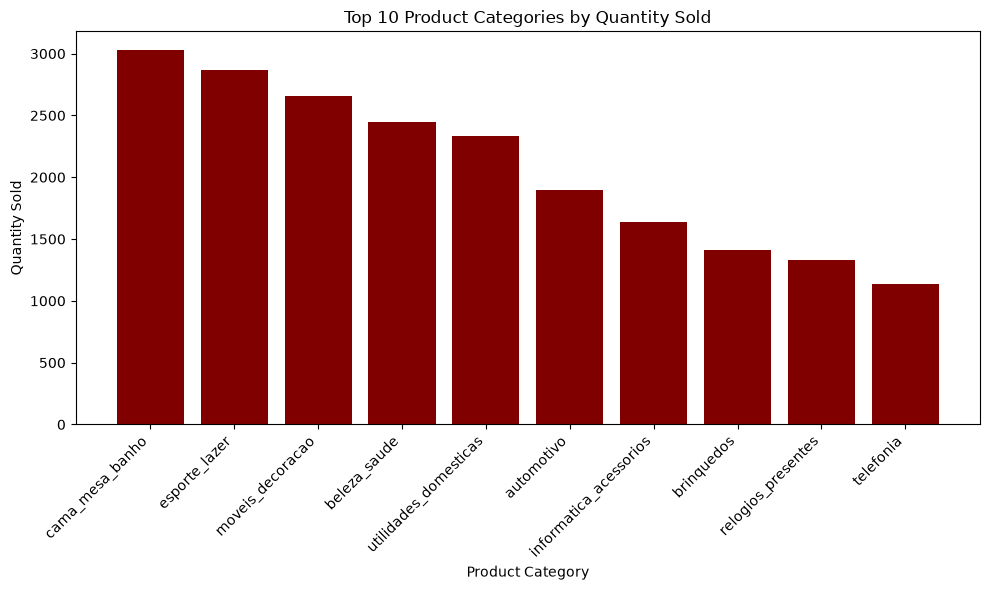

In [116]:
#product Categories's distribution visualization
import matplotlib.pyplot as plt

plt.style.use('default')

top_categories = category_quantity.head(10)

plt.figure(figsize=(10, 6))

plt.bar(
    top_categories['product_category_name'],
    top_categories['quantity_sold'],color='maroon'
)

plt.xticks(rotation=45, ha='right')
plt.xlabel('Product Category')
plt.ylabel('Quantity Sold')
plt.title('Top 10 Product Categories by Quantity Sold')

plt.tight_layout()
plt.savefig('top_10_categories.png')

plt.savefig('../dashboard/assets/top 10 product categories by Quantity.png')
plt.show()


Customer Analysis


In [67]:
#Total unique customers
Total_unique_customers=order['customer_id'].nunique()
print(Total_unique_customers)

99441


In [68]:
#Customers with only one order
customer_orders = order.groupby('customer_id')['order_id'].count()

one_order_c=(customer_orders==1).sum()

print(one_order_c)

99441


In [69]:
#Repeat customers
repeat_customers = (customer_orders > 1).sum()

print(repeat_customers)

0


In [70]:
#Top 10 customers by spending

customer_spending = order.merge(order_payments,on='order_id')

top_10_C=(customer_spending.groupby('customer_id')['payment_value'].sum()
.sort_values(ascending=False).head(10))
print(top_10_C)

customer_id
1617b1357756262bfa56ab541c47bc16    13664.08
ec5b2ba62e574342386871631fafd3fc     7274.88
c6e2731c5b391845f6800c97401a43a9     6929.31
f48d464a0baaea338cb25f816991ab1f     6922.21
3fd6777bbce08a352fddd04e4a7cc8f6     6726.66
05455dfa7cd02f13d132aa7a6a9729c6     6081.54
df55c14d1476a9a3467f131269c2477f     4950.34
e0a2412720e9ea4f26c1ac985f6a7358     4809.44
24bbf5fd2f2e1b359ee7de94defc4a15     4764.34
3d979689f636322c62418b6346b1c6d2     4681.78
Name: payment_value, dtype: float64


In [71]:
#Top 10 customers by number of orders
customer_orders = (order.groupby('customer_id')['order_id'].count().sort_values(ascending=False).head(10))
print(customer_orders)


customer_id
00012a2ce6f8dcda20d059ce98491703    1
000161a058600d5901f007fab4c27140    1
0001fd6190edaaf884bcaf3d49edf079    1
0002414f95344307404f0ace7a26f1d5    1
000379cdec625522490c315e70c7a9fb    1
0004164d20a9e969af783496f3408652    1
000419c5494106c306a97b5635748086    1
00046a560d407e99b969756e0b10f282    1
00050bf6e01e69d5c0fd612f1bcfb69c    1
000598caf2ef4117407665ac33275130    1
Name: order_id, dtype: int64


In [72]:
#Customer-wise total spending
customer_spending= order.merge(order_payments,on='order_id')
customer_total_spending= (
    customer_spending.groupby('customer_id')['payment_value'].sum().sort_values(ascending=False).head(3)
)
print(customer_total_spending)

customer_id
1617b1357756262bfa56ab541c47bc16    13664.08
ec5b2ba62e574342386871631fafd3fc     7274.88
c6e2731c5b391845f6800c97401a43a9     6929.31
Name: payment_value, dtype: float64


Delivery Analysis

In [73]:
#Average delivery time calculation

order['delivery_time'] = (
    order['order_delivered_customer_date']  - order['order_purchase_timestamp']
).dt.total_seconds() / (24 * 60 * 60)

avg_delivery_time = order['delivery_time'].mean()

print(avg_delivery_time)

12.558702304032053


In [74]:
#Har order ka delivery time calculate karo

order['delivery_time'] = (
    order['order_delivered_customer_date'] - order['order_purchase_timestamp']
).dt.total_seconds() / (24 * 60 * 60)

order[['order_id', 'delivery_time']].head(10)

,order_id,delivery_time
0,e481f51cbdc54678b7cc49136f2d6af7,8.436574
1,53cdb2fc8bc7dce0b6741e2150273451,13.782037
2,47770eb9100c2d0c44946d9cf07ec65d,9.394213
3,949d5b44dbf5de918fe9c16f97b45f8a,13.208750
4,ad21c59c0840e6cb83a9ceb5573f8159,2.873877
5,a4591c265e18cb1dcee52889e2d8acc3,16.542245
6,136cce7faa42fdb2cefd53fdc79a6098,NaN
7,6514b8ad8028c9f2cc2374ded245783f,9.989826
8,76c6e866289321a7c93b82b54852dc33,9.818762
9,e69bfb5eb88e0ed6a785585b27e16dbf,18.221852


In [75]:
#Late deliveries identification
order['late_delivery'] = (
 order['order_delivered_customer_date']
    > order['order_estimated_delivery_date']
)

late_orders = order[order['late_delivery'] == True]

print(late_orders[['order_id',
                   'order_delivered_customer_date',
                   'order_estimated_delivery_date']].head())

                            order_id order_delivered_customer_date  \
20  203096f03d82e0dffbc41ebc2e2bcfb7           2017-10-09 22:23:46   
25  fbf9ac61453ac646ce8ad9783d7d0af6           2018-03-21 22:03:54   
35  8563039e855156e48fccee4d611a3196           2018-03-20 00:59:25   
41  6ea2f835b4556291ffdc53fa0b3b95e8           2017-12-28 18:59:23   
57  66e4624ae69e7dc89bd50222b59f581f           2018-04-03 13:28:46   

   order_estimated_delivery_date  
20                    2017-09-28  
25                    2018-03-12  
35                    2018-03-20  
41                    2017-12-21  
57                    2018-04-02  


In [76]:
#Late delivery percentage calculate karo

late_percentage = order['late_delivery'].mean() * 100

print(late_percentage)

7.870998883760219


In [77]:
#State-wise average delivery time
state_delivery = order.merge(
    customers[['customer_id', 'customer_state']],
    on='customer_id'
)
state_avg_delivery = (
    state_delivery
    .groupby('customer_state')['delivery_time']
    .mean()
    .sort_values(ascending=False)
)
print(state_avg_delivery)

customer_state
RR    29.387546
AP    27.185068
AM    26.425991
AL    24.543855
PA    23.772917
MA    21.572976
SE    21.519788
CE    21.266579
AC    21.035713
PB    20.426768
PI    19.457098
RO    19.372037
BA    19.335466
RN    19.278156
PE    18.448323
MT    18.055756
TO    17.658063
ES    15.789307
MS    15.618319
GO    15.606339
RJ    15.310053
RS    15.300276
SC    14.959297
DF    12.967568
MG    12.010258
PR    11.991582
SP     8.761357
Name: delivery_time, dtype: float64


In [78]:
#Month-wise average delivery time
 #step1 create purchase month
order['purchase_month'] = (
    order['order_purchase_timestamp']
    .dt.to_period('M')
)

# step 2
monthly_avg_delivery = (
    order
    .groupby('purchase_month')['delivery_time']
    .mean()
)

print(monthly_avg_delivery)


purchase_month
2016-09    54.813194
2016-10    19.578572
2016-12     4.693021
2017-01    12.647044
2017-02    13.168825
2017-03    12.951184
2017-04    14.917913
2017-05    11.322363
2017-06    12.011573
2017-07    11.592732
2017-08    11.147125
2017-09    11.851007
2017-10    11.856700
2017-11    15.161132
2017-12    15.394919
2018-01    14.080563
2018-02    16.947143
2018-03    16.301410
2018-04    11.499241
2018-05    11.419029
2018-06     9.239216
2018-07     8.958636
2018-08     7.732780
2018-09          NaN
2018-10          NaN
Freq: M, Name: delivery_time, dtype: float64


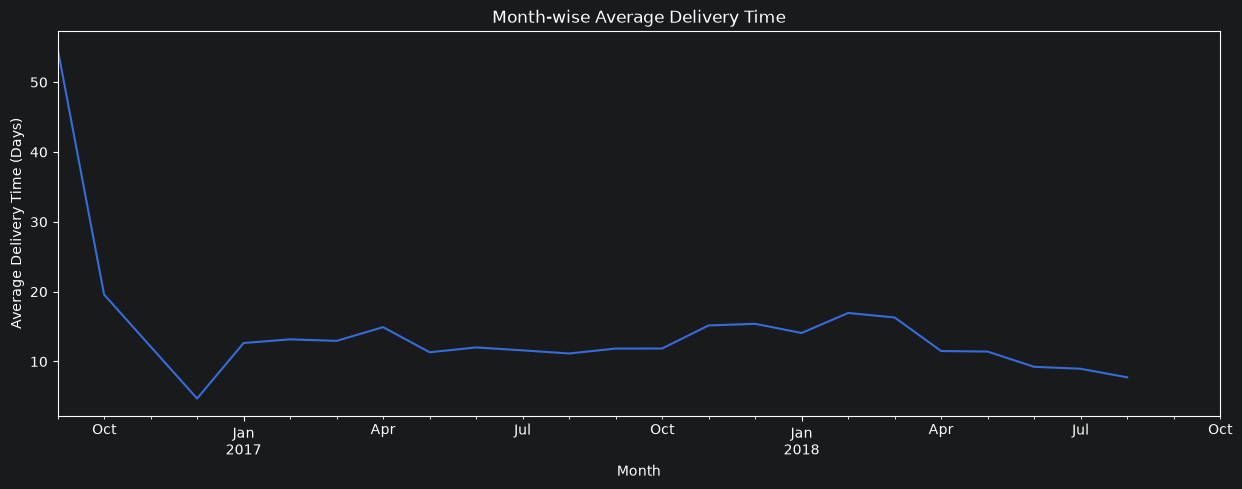

In [115]:
# visualization
monthly_avg_delivery.plot(
    kind='line',
    figsize=(15, 5),
    title='Month-wise Average Delivery Time'
)

plt.xlabel('Month')
plt.ylabel('Average Delivery Time (Days)')

plt.savefig('../dashboard/assets/Month-wise Average Delivery Time.png')
plt.show()

Review Analysis


Payment Analysis

In [80]:
#Total payment value
total_payment=order_payments['payment_value'].sum()
print(total_payment)

16008872.120000001


In [81]:
#Payment types ka distribution
payment_distribution = order_payments['payment_type'].value_counts()

print(payment_distribution)

payment_type
credit_card    76795
boleto         19784
voucher         5775
debit_card      1529
not_defined        3
Name: count, dtype: int64


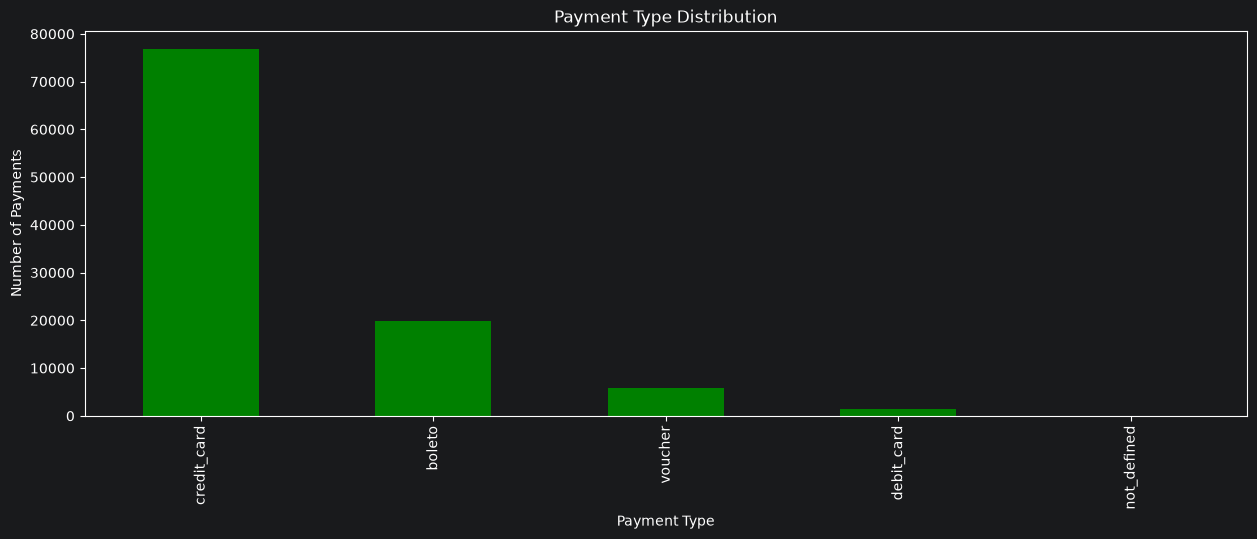

In [113]:
#visualization
payment_distribution.plot( kind='bar',figsize=(15, 5),
title='Payment Type Distribution',color='green')

plt.xlabel('Payment Type')
plt.ylabel('Number of Payments')

plt.savefig('../dashboard/assets/Payment Type Distribution.png')
plt.show()

In [83]:
#Payment type-wise transaction count
payment_type_value=(order_payments.groupby('payment_type').size().sort_values(ascending=False))


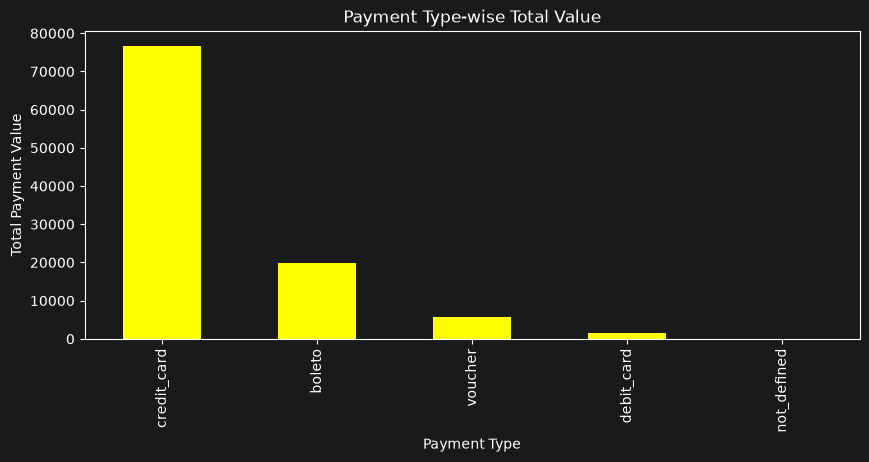

In [114]:
payment_type_value.plot(
    kind='bar',
    figsize=(10, 4),
    title='Payment Type-wise Total Value',color='yellow'
)

plt.xlabel('Payment Type')
plt.ylabel('Total Payment Value')

plt.savefig('../dashboard/assets/Payment Type-wise Total Value.png')
plt.show()

In [85]:
#Average payment value
avg_payment=(order_payments['payment_value'].mean())
print(avg_payment)

154.10038041699556
